In [17]:
#to-do
#create an copy of original
#clean column names, string values in it
#drop duplicates
#check if all nA values need to be removed?
#create new cols that will help in future metrics

In [43]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/user_events_ecommerce_product_analytics.csv")
df_clean = df.copy()
df_clean.columns = df_clean.columns.str.strip().str.lower()
text_cols = ["event_type", "device", "traffic_source", "country", "city", "category"]
for col in text_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.lower()


#merge date and time into timestamp
df_clean["event_timestamp"] = pd.to_datetime(
    df_clean["event_date"].astype(str) + " " + df_clean["event_time"].astype(str),
    errors="coerce"
)


before_dup = len(df_clean)
df_clean = df_clean.drop_duplicates()
after_dup = len(df_clean)
print("Duplicates removed:", before_dup - after_dup)

df_clean["price_present"] = df_clean["price"].notna().astype(int)

df_clean["invalid_price"] = df_clean["price"].notna() & (df_clean["price"] <= 0)

df_clean["bad_timestamp"] = df_clean["event_timestamp"].isna()

df_clean = df_clean.sort_values(["user_id", "session_id", "event_timestamp"])


df_clean["event_date_only"] = df_clean["event_timestamp"].dt.date
df_clean["event_hour"] = df_clean["event_timestamp"].dt.hour
df_clean["day_of_week"] = df_clean["event_timestamp"].dt.day_name()

# cleaned dataset saved to csv
df_clean.to_csv("../data/cleaned_user_events.csv", index=False)

print("Invalid prices found:", df_clean["invalid_price"].sum())
print("Bad timestamps found:", df_clean["bad_timestamp"].sum())
df_clean.head(5)

Duplicates removed: 0
Invalid prices found: 0
Bad timestamps found: 0


,user_id,session_id,event_date,event_time,event_type,product_id,category,price,device,traffic_source,country,city,event_timestamp,price_present,invalid_price,bad_timestamp,event_date_only,event_hour,day_of_week
220361,U100000,S1085471,2024-04-01,04:41:00,view,P4277,jeans,NaN,web,ads,germany,berlin,2024-04-01 04:41:00,0,False,False,2024-04-01,4,Monday
1890,U100000,S1303026,2024-01-26,02:09:00,visit,P6606,formal wear,NaN,web,organic,germany,berlin,2024-01-26 02:09:00,0,False,False,2024-01-26,2,Friday
227201,U100000,S1485879,2024-06-14,20:18:00,checkout,P9863,men pants,4791.33,web,ads,uk,london,2024-06-14 20:18:00,1,False,False,2024-06-14,20,Friday
138277,U100000,S2102407,2024-03-16,14:45:00,add_to_cart,P2593,women pants,3220.34,mobile,organic,india,mumbai,2024-03-16 14:45:00,1,False,False,2024-03-16,14,Saturday
170932,U100000,S2139541,2024-01-24,05:14:00,visit,P6605,jeans,NaN,mobile,ads,australia,melbourne,2024-01-24 05:14:00,0,False,False,2024-01-24,5,Wednesday


In [ ]:
#data cleaning steps performed:
#1. created a copy of original dataset, saved cleaned dataset to csv
#2. standardized column names and string values in text columns
#3. validated price data and confirmed that all price values are positive numbers, created new columns to identify missing and invalid prices
#4. checked for duplicate rows - none found
#5. preserved price value for event_type "view" and "visit" to maintain realistic event behavior.
#6. merged date and time into a single timestamp column, created new columns for date, hour, and day of week to facilitate future analysis


In [40]:
funnel_users = (
    df_clean.groupby("event_type")["user_id"]
    .nunique()
    .reset_index()
)

funnel_users.columns = ["event_type", "unique_users"]
funnel_users = funnel_users.sort_values(
    "unique_users", ascending=False
).reset_index(drop=True)

funnel_users["conversion_from_previous"] = (
    (funnel_users["unique_users"] / funnel_users["unique_users"].shift(1)
) * 100).round(2)

funnel_users

,event_type,unique_users,conversion_from_previous
0,view,11998,NaN
1,visit,11995,99.97
2,add_to_cart,11888,99.11
3,checkout,11533,97.01
4,purchase,10566,91.62


In [ ]:
#funnel insights:
#1. Doesn't give a clear picture as the drop off rates seem quite non-realisitc. Given this is synthetic data, it is possible. 
#2. The above funnel looks overly simplified because of the unique users count. The dataset is spread over 12 months, and users may have multiple sessions and events. So, the unique user count for each event type may not accurately reflect the true funnel behavior, as users can appear in multiple stages of the funnel across different sessions and time periods.
#2. Hence, I'll break down to granural funnel (per session)

In [ ]:
#session-funnel analysis
funnel_steps = [
    "visit",
    "view",
    "add_to_cart",
    "checkout",
    "purchase"
]

step_map = {step: i for i, step in enumerate(funnel_steps)}

df_funnel = df_clean[df_clean["event_type"].isin(funnel_steps)].copy()

df_funnel["step_num"] = df_funnel["event_type"].map(step_map)

# get max step reached per session
session_progress = (
    df_funnel.groupby("session_id")["step_num"]
    .max()
    .reset_index()
)

funnel_counts = []

total_sessions = len(session_progress)

for i, step in enumerate(funnel_steps):
    
    reached = (session_progress["step_num"] >= i).sum()
    
    funnel_counts.append({
        "event_type": step,
        "sessions_reached": reached
    })

funnel_df = pd.DataFrame(funnel_counts)

funnel_df["conversion_from_previous"] = (
    funnel_df["sessions_reached"]
    .pct_change()
    .add(1)
    .mul(100)
    .round(2)
)

funnel_df["dropoff_rate"] = (
    100 - funnel_df["conversion_from_previous"]
)

funnel_df

,event_type,sessions_reached,conversion_from_previous,dropoff_rate
0,visit,314284,NaN,NaN
1,view,221464,70.47,29.53
2,add_to_cart,121019,54.64,45.36
3,checkout,63765,52.69,47.31
4,purchase,25471,39.95,60.05


In [ ]:
#Granular funnel insights:
#1. Visit -> view: 70% is pretty decent, meaning product pages are engaging enough, Users are showing initial interest and traffic quality is good.
#2. View -> add_to_cart: drop off is 45%, meaning low product appeal or pricing issues. It could also be using treating the platform only to browse. (needs analysis later)
#3. Add_to_cart -> checkout: drop off is 47%, indicating any hidden costs, lengthy checkout process, or lack of payment options. (needs RCA)
#4. Checkout -> purchase: highest drop off - 60%, indicating checkout friction, payment issues, no offers, security concerns etc. (needs RCA)
#Mid-funnel degradation is a common issue in e-commerce, further analysis needs to be done to identify pain points and optimize the funnel.

In [50]:
#I'm gonna remove further unused columns to declutter the dataset i.e, "price_present", "invalid_price", "bad_timestamp" as they all came out to be 0 in the previous checks.
df_clean = df_clean.drop(columns=["price_present", "invalid_price", "bad_timestamp"])

In [68]:
#mid-funnel RCA:
#Index([, 'category', 'price', 'device', 'traffic_source','country', 'city', 'event_timestamp', 'day_of_week'],
#the above can be considered potential factors impacting mid-funnel drop off.

#1. Traffic source analysis:
traffic_funnel = (
    df_funnel.groupby(["traffic_source", "event_type"])["session_id"]
    .nunique()
    .unstack()
)
traffic_funnel["visit_to_view_dropoff"] = (
    100 - (traffic_funnel["view"] / traffic_funnel["visit"] * 100).round(2)
)

traffic_funnel["view_to_cart_dropoff"] = (
    100 - (traffic_funnel["add_to_cart"] / traffic_funnel["view"] * 100).round(2)
)

traffic_funnel["cart_to_checkout_dropoff"] = (
    100 - (traffic_funnel["checkout"] / traffic_funnel["add_to_cart"] * 100).round(2)
)

traffic_funnel["checkout_to_purchase_dropoff"] = (
    100 - (traffic_funnel["purchase"] / traffic_funnel["checkout"] * 100).round(2)
)

traffic_funnel[["visit_to_view_dropoff", "view_to_cart_dropoff", 
                "cart_to_checkout_dropoff", "checkout_to_purchase_dropoff"]]



event_type,visit_to_view_dropoff,view_to_cart_dropoff,cart_to_checkout_dropoff,checkout_to_purchase_dropoff
traffic_source,,,,
ads,-6.87,43.18,34.85,32.32
email,-6.41,43.18,33.29,33.70
organic,-7.16,43.91,31.95,34.32
referral,-6.96,43.72,33.38,34.56


In [ ]:
#not much difference across traffic sources, hence thats not a factor impacting mid-funnel drop off.

In [71]:
traffic_funnel = (
    df_funnel.groupby(["device", "event_type"])["session_id"]
    .nunique()
    .unstack()
)
traffic_funnel["visit_to_view_dropoff"] = (
    100 - (traffic_funnel["view"] / traffic_funnel["visit"] * 100).round(2)
)

traffic_funnel["view_to_cart_dropoff"] = (
    100 - (traffic_funnel["add_to_cart"] / traffic_funnel["view"] * 100).round(2)
)

traffic_funnel["cart_to_checkout_dropoff"] = (
    100 - (traffic_funnel["checkout"] / traffic_funnel["add_to_cart"] * 100).round(2)
)

traffic_funnel["checkout_to_purchase_dropoff"] = (
    100 - (traffic_funnel["purchase"] / traffic_funnel["checkout"] * 100).round(2)
)

traffic_funnel[["visit_to_view_dropoff", "view_to_cart_dropoff", 
                "cart_to_checkout_dropoff", "checkout_to_purchase_dropoff"]]

event_type,visit_to_view_dropoff,view_to_cart_dropoff,cart_to_checkout_dropoff,checkout_to_purchase_dropoff
device,,,,
mobile,-6.77,43.68,32.94,34.18
web,-6.93,43.23,33.84,33.22


In [ ]:
#not much difference across devices as well, hence thats not a factor impacting mid-funnel drop off.

In [72]:
traffic_funnel = (
    df_funnel.groupby(["country","city", "event_type"])["session_id"]
    .nunique()
    .unstack()
)
traffic_funnel["visit_to_view_dropoff"] = (
    100 - (traffic_funnel["view"] / traffic_funnel["visit"] * 100).round(2)
)

traffic_funnel["view_to_cart_dropoff"] = (
    100 - (traffic_funnel["add_to_cart"] / traffic_funnel["view"] * 100).round(2)
)

traffic_funnel["cart_to_checkout_dropoff"] = (
    100 - (traffic_funnel["checkout"] / traffic_funnel["add_to_cart"] * 100).round(2)
)

traffic_funnel["checkout_to_purchase_dropoff"] = (
    100 - (traffic_funnel["purchase"] / traffic_funnel["checkout"] * 100).round(2)
)

traffic_funnel[["visit_to_view_dropoff", "view_to_cart_dropoff", 
                "cart_to_checkout_dropoff", "checkout_to_purchase_dropoff"]]

event_type               visit_to_view_dropoff  view_to_cart_dropoff  \
country   city                                                         
australia melbourne                      -4.62                 41.97   
          sydney                         -7.73                 45.09   
germany   berlin                         -6.13                 43.60   
          munich                         -9.26                 43.33   
india     bangalore                      -8.37                 42.42   
          delhi                          -6.79                 45.52   
          hyderabad                      -3.83                 43.08   
          mumbai                         -9.80                 44.87   
          pune                           -6.82                 43.79   
uk        london                         -4.01                 41.63   
          manchester                     -7.99                 44.64   
usa       austin                         -5.32                 42.47   
          chicago                        -8.60                 42.71   
          new york                       -4.85                 43.68   
          san francisco                 -10.33                 44.82   

event_type               cart_to_checkout_dropoff  \
country   city                                      
australia melbourne                         33.13   
          sydney                            32.99   
germany   berlin                            34.10   
          munich                            34.34   
india     bangalore                         32.39   
          delhi                             34.12   
          hyderabad                         33.76   
          mumbai                            31.18   
          pune                              33.62   
uk        london                            33.70   
          manchester                        33.82   
usa       austin                            33.60   
          chicago                           34.02   
          new york                          32.22   
          san francisco                     31.72   

event_type               checkout_to_purchase_dropoff  
country   city                                         
australia melbourne                             35.44  
          sydney                                31.14  
germany   berlin                                33.25  
          munich                                35.05  
india     bangalore                             34.72  
          delhi                                 28.43  
          hyderabad                             33.46  
          mumbai                                36.97  
          pune                                  32.69  
uk        london                                34.10  
          manchester                            33.47  
usa       austin                                33.63  
          chicago                               35.58  
          new york                              34.22  
          san francisco                         33.14

In [ ]:
#not much difference across geographies as well, hence thats not a factor impacting mid-funnel drop off.

In [109]:
df_funnel["month"] = pd.to_datetime(df_funnel["event_date"]).dt.to_period("M")

monthly_sessions = df_funnel.groupby("month")["session_id"].nunique().reset_index()
monthly_sessions.columns = ["month", "session_count"]

monthly_sessions["mom_change"] = monthly_sessions["session_count"].pct_change().mul(100).round(2)

print(monthly_sessions)

      month  session_count  mom_change
0   2024-01          27063         NaN
1   2024-02          25463       -5.91
2   2024-03          26902        5.65
3   2024-04          26421       -1.79
4   2024-05          26858        1.65
5   2024-06          26578       -1.04
6   2024-07          26700        0.46
7   2024-08          27143        1.66
8   2024-09          26256       -3.27
9   2024-10          26835        2.21
10  2024-11          26287       -2.04
11  2024-12          26996        2.70


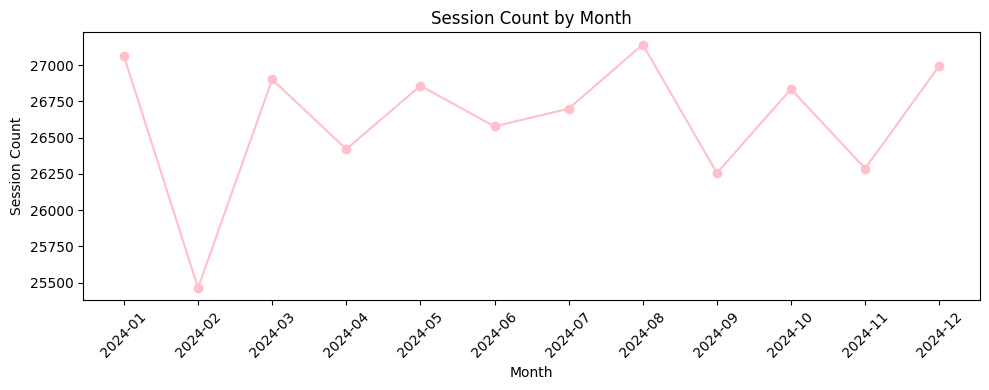

In [ ]:
monthly_sessions["month"] = monthly_sessions["month"].astype(str)

plt.figure(figsize=(10, 4))
plt.plot(monthly_sessions["month"], monthly_sessions["session_count"], marker="o", color="pink")
plt.xlabel("Month")
plt.ylabel("Session Count")
plt.title("Session Count by Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
#From above we can see a huge drop off in sessions in the month february, which could be the cause of mid-funnel drop off. If no other factors found in the future, this could be a potential reason and needs an investigation as to what changes have been made in february.

In [ ]:
#Just want to cross check, if the session drop off in february is any specific to any traffic source, device, or geography.

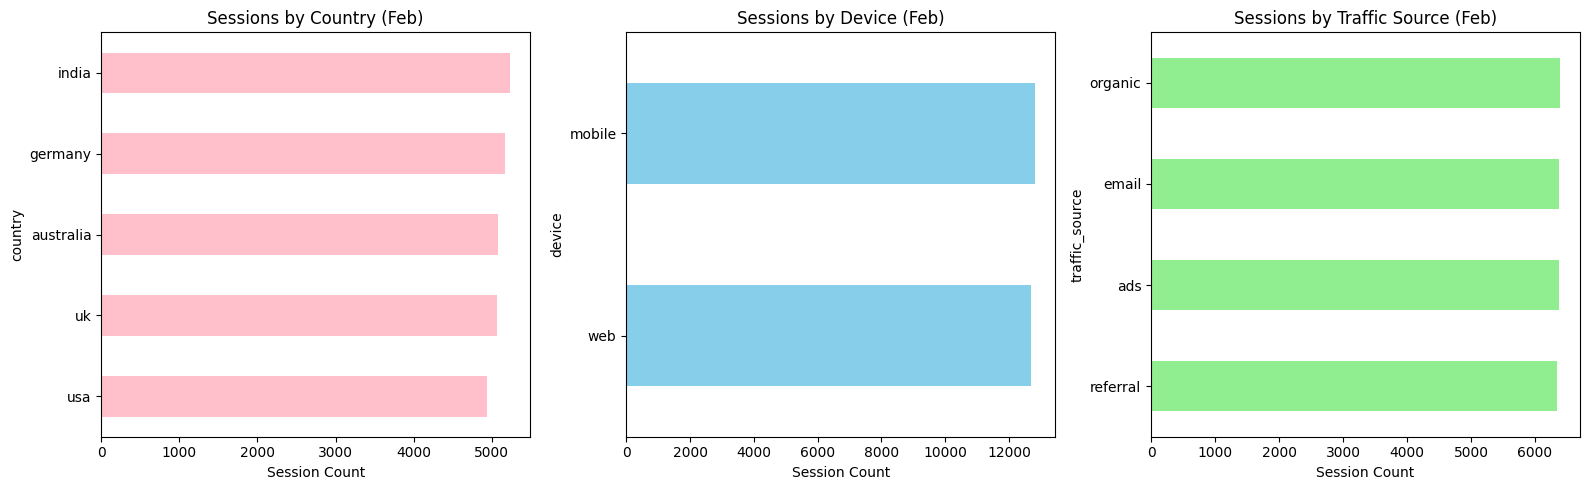

In [111]:
df_funnel["month"] = pd.to_datetime(df_funnel["event_date"]).dt.to_period("M")
df_feb = df_funnel[df_funnel["month"] == "2024-02"]  # filter february

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. by country
df_feb.groupby("country")["session_id"].nunique().sort_values().plot(
    kind="barh", ax=axes[0], color="pink"
)
axes[0].set_title("Sessions by Country (Feb)")
axes[0].set_xlabel("Session Count")

# 2. by device
df_feb.groupby("device")["session_id"].nunique().sort_values().plot(
    kind="barh", ax=axes[1], color="skyblue"
)
axes[1].set_title("Sessions by Device (Feb)")
axes[1].set_xlabel("Session Count")

# 3. by traffic source
df_feb.groupby("traffic_source")["session_id"].nunique().sort_values().plot(
    kind="barh", ax=axes[2], color="lightgreen"
)
axes[2].set_title("Sessions by Traffic Source (Feb)")
axes[2].set_xlabel("Session Count")

plt.tight_layout()
plt.show()

In [ ]:
#Not much difference across traffic sources, devices, or geographies in february as well, hence the session drop off in february is not specific to any of these factors. Hence, I can conclude that whatever has gotten the session drop off in february is a more systemic issue, and not specific to any particular segment. Hence, it needs to be investigated from a more holistic perspective, like changes in marketing strategy, website/app changes, external factors etc.

In [81]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df_funnel["day_of_week"] = pd.Categorical(df_funnel["day_of_week"], categories=day_order, ordered=True)

traffic_funnel = (
    df_funnel.groupby(["day_of_week", "event_type"])["session_id"]
    .nunique()
    .unstack()
)
traffic_funnel["visit_to_view_dropoff"] = (
    100 - (traffic_funnel["view"] / traffic_funnel["visit"] * 100).round(2)
)

traffic_funnel["view_to_cart_dropoff"] = (
    100 - (traffic_funnel["add_to_cart"] / traffic_funnel["view"] * 100).round(2)
)

traffic_funnel["cart_to_checkout_dropoff"] = (
    100 - (traffic_funnel["checkout"] / traffic_funnel["add_to_cart"] * 100).round(2)
)

traffic_funnel["checkout_to_purchase_dropoff"] = (
    100 - (traffic_funnel["purchase"] / traffic_funnel["checkout"] * 100).round(2)
)

traffic_funnel[["visit_to_view_dropoff", "view_to_cart_dropoff", 
                "cart_to_checkout_dropoff", "checkout_to_purchase_dropoff"]]

event_type,visit_to_view_dropoff,view_to_cart_dropoff,cart_to_checkout_dropoff,checkout_to_purchase_dropoff
day_of_week,,,,
Monday,-6.90,43.55,33.01,34.95
Tuesday,-7.70,43.55,33.65,33.65
Wednesday,-7.75,44.47,32.85,32.73
Thursday,-6.31,42.96,33.29,34.92
Friday,-7.99,42.93,35.49,34.31
Saturday,-6.20,43.58,32.42,33.82
Sunday,-5.05,43.50,32.97,31.77


In [ ]:
#not huge difference across days of week as well, though drop off seems slightly higher on weekends, which could be due to more casual browsing behavior. But overall, day of week doesn't seem to be a major factor impacting mid-funnel drop off.

In [85]:
df_funnel["time_of_day"] = pd.cut(
    df_funnel["event_hour"],
    bins=[0, 6, 12, 18, 21, 24],
    labels=["night", "morning", "afternoon", "evening", "late_night"],
    right=False
)
traffic_funnel = (
    df_funnel.groupby(["time_of_day", "event_type"])["session_id"]
    .nunique()
    .unstack()
)
traffic_funnel["visit_to_view_dropoff"] = (
    100 - (traffic_funnel["view"] / traffic_funnel["visit"] * 100).round(2)
)

traffic_funnel["view_to_cart_dropoff"] = (
    100 - (traffic_funnel["add_to_cart"] / traffic_funnel["view"] * 100).round(2)
)

traffic_funnel["cart_to_checkout_dropoff"] = (
    100 - (traffic_funnel["checkout"] / traffic_funnel["add_to_cart"] * 100).round(2)
)

traffic_funnel["checkout_to_purchase_dropoff"] = (
    100 - (traffic_funnel["purchase"] / traffic_funnel["checkout"] * 100).round(2)
)

traffic_funnel[["visit_to_view_dropoff", "view_to_cart_dropoff", 
                "cart_to_checkout_dropoff", "checkout_to_purchase_dropoff"]]

event_type,visit_to_view_dropoff,view_to_cart_dropoff,cart_to_checkout_dropoff,checkout_to_purchase_dropoff
time_of_day,,,,
night,-5.64,42.49,34.08,33.54
morning,-6.91,43.07,33.67,34.05
afternoon,-7.16,44.06,33.62,32.59
evening,-8.18,44.15,32.79,34.38
late_night,-7.11,44.58,31.49,35.05


In [ ]:
#barely any difference but what we can infer is that if you wanna run any campaigns, afternoon seems to be the best time to target users as drop off is lowest across purchase funnel.
#time of the day has minimal to no impact on mid-funnel drop off as well.

In [86]:
traffic_funnel = (
    df_funnel.groupby(["product_id","category", "event_type"])["session_id"]
    .nunique()
    .unstack()
)
traffic_funnel["visit_to_view_dropoff"] = (
    100 - (traffic_funnel["view"] / traffic_funnel["visit"] * 100).round(2)
)

traffic_funnel["view_to_cart_dropoff"] = (
    100 - (traffic_funnel["add_to_cart"] / traffic_funnel["view"] * 100).round(2)
)

traffic_funnel["cart_to_checkout_dropoff"] = (
    100 - (traffic_funnel["checkout"] / traffic_funnel["add_to_cart"] * 100).round(2)
)

traffic_funnel["checkout_to_purchase_dropoff"] = (
    100 - (traffic_funnel["purchase"] / traffic_funnel["checkout"] * 100).round(2)
)

traffic_funnel[["visit_to_view_dropoff", "view_to_cart_dropoff", 
                "cart_to_checkout_dropoff", "checkout_to_purchase_dropoff"]]

event_type              visit_to_view_dropoff  view_to_cart_dropoff  \
product_id category                                                   
P1000      casual wear                -100.00               -150.00   
           formal wear                  50.00                  0.00   
           jeans                       -66.67                   NaN   
           men pants                   -50.00                  0.00   
           women pants                -100.00                   NaN   
...                                       ...                   ...   
P9999      casual wear                -100.00                 50.00   
           formal wear                  50.00               -100.00   
           jeans                       -50.00                 33.33   
           men pants                     0.00                 50.00   
           women pants                 -50.00                 66.67   

event_type              cart_to_checkout_dropoff  checkout_to_purchase_dropoff  
product_id category                                                             
P1000      casual wear                       NaN                           NaN  
           formal wear                      0.00                           NaN  
           jeans                             NaN                           NaN  
           men pants                       66.67                           NaN  
           women pants                       NaN                           NaN  
...                                          ...                           ...  
P9999      casual wear                       NaN                           NaN  
           formal wear                       NaN                           NaN  
           jeans                             NaN                           NaN  
           men pants                         NaN                           NaN  
           women pants                      0.00                           NaN  

[44962 rows x 4 columns]

In [ ]:
#Segmentation RCA across traffic source, device, geography, time, and product category showed no statistically significant variance in drop-off rates, suggesting the funnel drop-off is systemic rather than segment-specific. Root cause likely lies in data quality issues or user experience factors not captured in the current synthetic dataset.

In [87]:
import sqlite3
conn = sqlite3.connect("../data/cleaned_user_events.db")
df_clean.to_sql(
    "cleaned_user_events",
    conn,
    if_exists="replace",
    index=False
)


320000

In [91]:
query = """select event_type, count(distinct session_id) as sessions from cleaned_user_events group by event_type"""
pd.read_sql(query, conn)

,event_type,sessions
0,add_to_cart,57643
1,checkout,38420
2,purchase,25471
3,view,101800
4,visit,95300


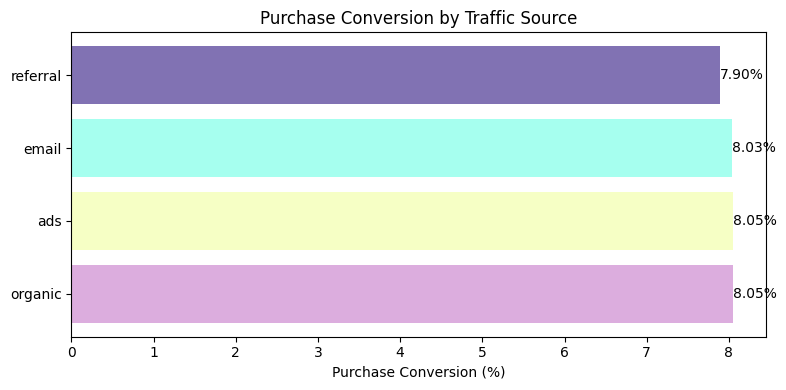

In [104]:
#traffic source purchase conversion plot

query = """select traffic_source,
    count(distinct case when event_type='purchase' then session_id end)*100.0 /
    count(distinct session_id) as purchase_conversion from cleaned_user_events group by traffic_source order by purchase_conversion desc"""
traffic_funnel = pd.read_sql(query, conn)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.barh(traffic_funnel["traffic_source"], traffic_funnel["purchase_conversion"], color= ["#dcadde", "#f6ffc5", "#a6ffef", "#8172b3"])
plt.xlabel("Purchase Conversion (%)")
plt.title("Purchase Conversion by Traffic Source")
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, 
            f"{width:.2f}%", va="center", ha="left")
plt.tight_layout()
plt.show()


In [ ]:
query = """select traffic_source,
    count(distinct case when event_type='purchase' then session_id end)*100.0 /
    count(distinct session_id) as purchase_conversion from cleaned_user_events group by traffic_source order by purchase_conversion desc"""
traffic_funnel = pd.read_sql(query, conn)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.barh(traffic_funnel["traffic_source"], traffic_funnel["purchase_conversion"])
plt.xlabel("Purchase Conversion (%)")
plt.title("Purchase Conversion by Traffic Source")
plt.tight_layout()
plt.show()


In [ ]:
#for other plots of performed RCA, Just exchange the variable in the above query and plot accordingly. Since RCA has bought me to no conclusion I wont be plotting other variables as of now.

In [ ]:
#### Conclusion:
# The analysis revealed that the most significant drop-off occurred between checkout and purchase,
# indicating that many users initiated the checkout process but did not complete their purchase.
# To identify the root cause, multiple factors were examined including traffic source, device type,
# location, time patterns, and product categories. None of these segments showed meaningful variance
# in drop-off rates, suggesting the issue is systemic rather than segment-specific.

# However, a notable spike in session drop-offs was observed in February, which stands out as the
# key anomaly in the data. Since no segmentation factor explained this, it is recommended to 
# investigate whether any changes were made during this period — such as app or website updates,
# product catalog or pricing changes, delivery or logistics disruptions, or any A/B tests that 
# were active in February — as these could have introduced friction that impacted user behavior
# platform-wide.

# Overall, the findings suggest that improving the general checkout experience and investigating
# the February anomaly should be the primary focus for reducing drop-offs and improving
# conversion rates.